In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway

## Загрузка данных и первичный анализ

In [2]:
url = 'https://raw.githubusercontent.com/aiedu-courses/eda_and_dev_tools/refs/heads/main/datasets/abalone.csv'
df = pd.read_csv(url)

In [3]:
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,NaN,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [4]:
df.shape

(4177, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4078 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4078 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4127 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [6]:
df.describe(include='number')

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4078.000000,4177.000000,4078.000000,4177.000000,4177.000000,4127.000000,4177.000000
mean,0.523992,0.407840,0.139516,0.827306,0.359367,0.180594,0.239072,9.933684
std,0.120093,0.099286,0.041827,0.490348,0.221963,0.109614,0.138942,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.440500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.798500,0.336000,0.171000,0.235000,9.000000
75%,0.615000,0.480000,0.165000,1.150875,0.502000,0.253000,0.328250,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [7]:
df.describe(include='object')

,Sex
count,4177
unique,4
top,M
freq,1447


In [8]:
df.isnull().mean() * 100

,0
Sex,0.000000
Length,0.000000
Diameter,2.370122
Height,0.000000
Whole weight,2.370122
Shucked weight,0.000000
Viscera weight,0.000000
Shell weight,1.197031
Rings,0.000000


In [9]:
df[['Diameter', 'Whole weight', 'Shell weight', 'Rings']].corr()

,Diameter,Whole weight,Shell weight,Rings
Diameter,1.000000,0.925855,0.904425,0.572446
Whole weight,0.925855,1.000000,0.954968,0.539512
Shell weight,0.904425,0.954968,1.000000,0.625696
Rings,0.572446,0.539512,0.625696,1.000000


In [10]:
df.duplicated().sum()

np.int64(0)

**Промежуточный вывод:**
- В датасете 4177 объектов и 9 признаков, 8 из которых числовые, и 1 категориальный.
- В данных присутствуют выбросы, например, в признаке Height при медиане, равно 0.14, максимальное значение признака - 1.13. Схожая ситуация в признаках Whole weight и Shucked weight, однако размер максимальных значений не позволяет думать, что это ошибка в расчётах - скорее есть небольшое количество дейтсвительно больших морских ушек, поэтому от таких данных избавляться не будем.
- В признаках Diameter, Whole weight и Shell weight отсутствуют от 1.2% до 2.4% значений. Это совсем мало, но и датасет у нас небольшой. Была построена матрица корреляции между этими признаками и таргетом, чтобы понять, следует объекты с пустыми значениями просто удалить, или они таки важны для таргета. Корреляция получилась средняя от 0.54 до 0.63. В общем, можно оставить, можно удалить. Я оставлю, заполню пропуски медианным значением.

In [11]:
for col in ['Diameter', 'Whole weight', 'Shell weight']:
    df[col] = df[col].fillna(df[col].median())

## Однофакторный анализ

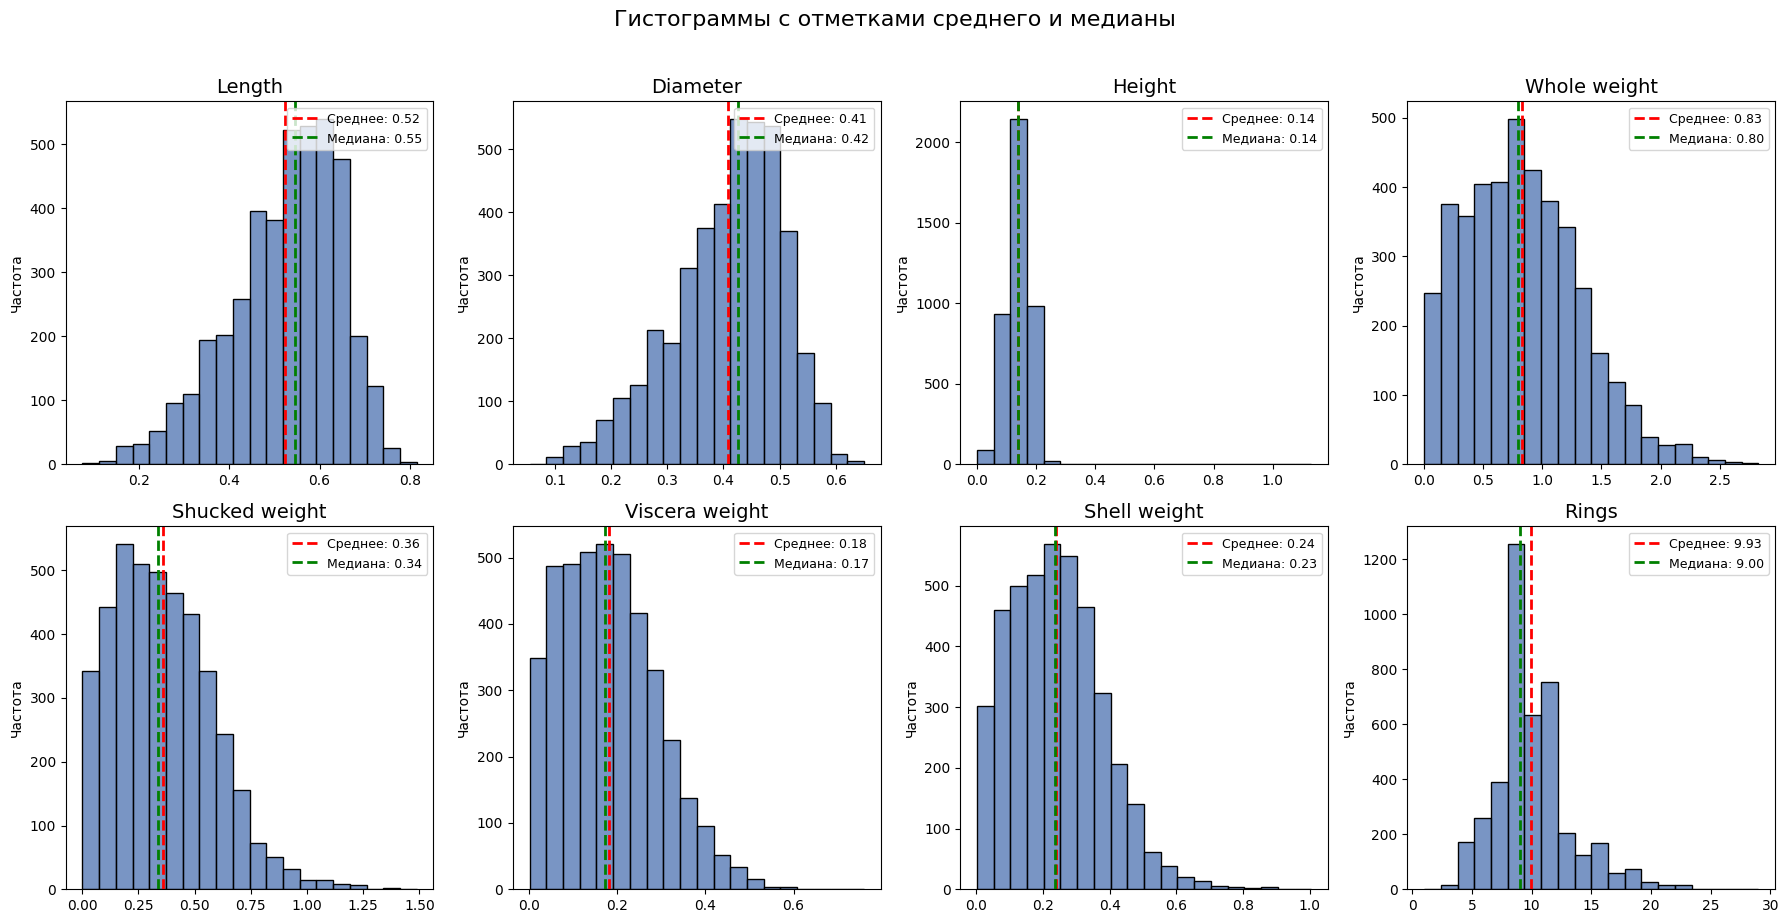

In [12]:
cols = df.select_dtypes(include='number').columns

n_cols = 4
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 9))
axes = axes.ravel()

for i, col in enumerate(cols):
    ax = axes[i]
    sns.histplot(data=df, x=col, bins=20, kde=False, ax=ax, color='#4c72b0')

    mean_val = df[col].mean()
    median_val = df[col].median()

    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_val:.2f}')

    ax.set_title(col, fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('Частота')
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle('Гистограммы с отметками среднего и медианы', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

**Промежуточный вывод:**
- Признаки Whole weight, Shucked weight, Viscera weight, Shell weight имеют логнормальное распределение. Остальные близки к нормальному или нормальное распределение.
- Среднее и медиана практически равны у всех признаков. Небольшое различие есть только у таргета, среднее больше медианы, значит существует небольшое число великовозрастных морских ушек.
- График Height и впрямь выглядит так, словно там есть выбросы, хотя медиана и среднее совпадает.
- У таргета распределение, близкое к нормальному. Проблемы сулит классические - данных, находящихся в хвостах, мало, поэтому модель хуже на них обучится и будет чаще на них ошибаться.

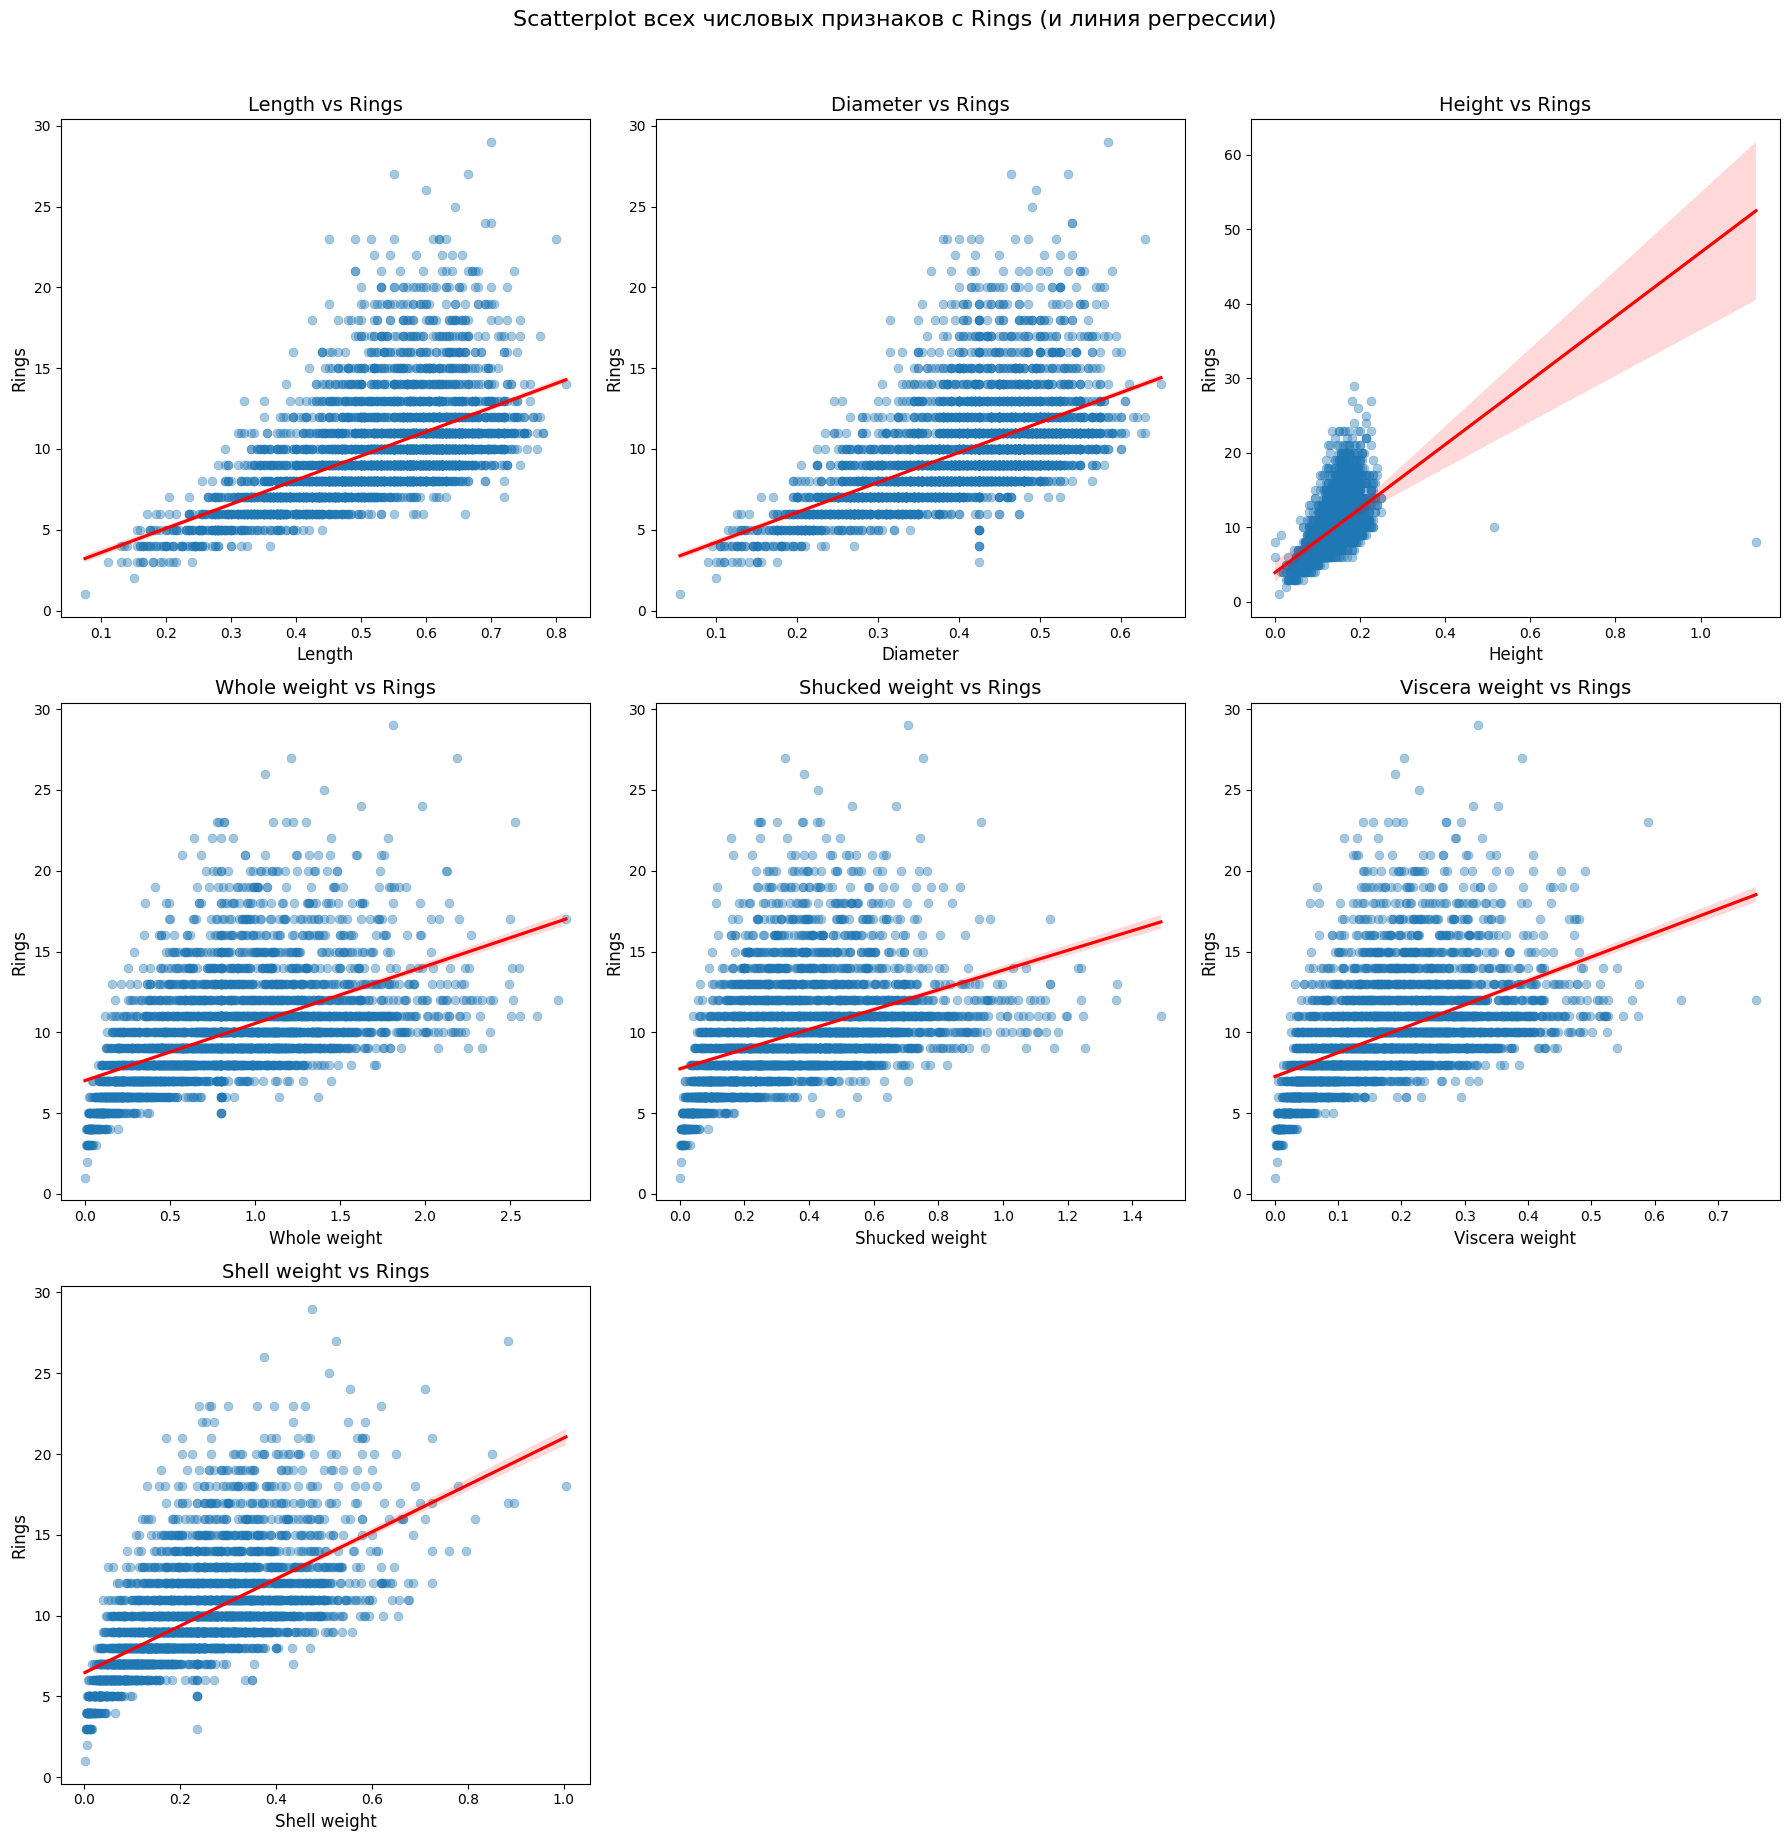

In [13]:
# список числовых признаков (без Sex и Rings как предикторов)
num_cols = ['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight']
target = 'Rings'

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.scatterplot(data=df, x=col, y=target, alpha=0.4, s=40, ax=ax, edgecolor=None)
    sns.regplot(data=df, x=col, y=target, scatter=False, color='red', ax=ax)
    ax.set_title(f'{col} vs {target}', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Rings', fontsize=12)

# убираем пустые подграфики, если их больше чем нужно
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Scatterplot всех числовых признаков с Rings (и линия регрессии)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

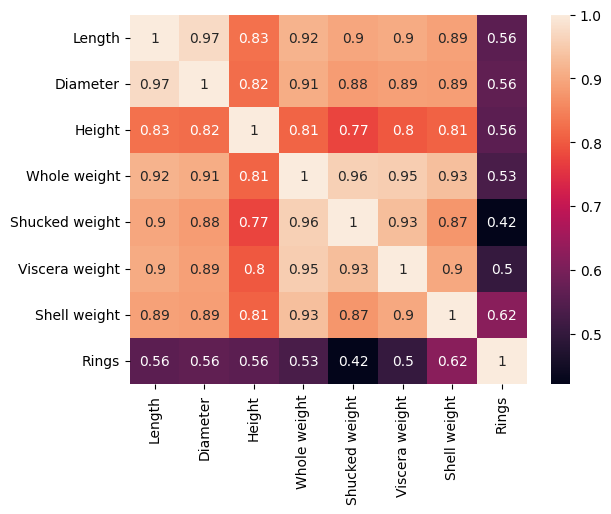

In [14]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True);

**Промежуточный вывод:**
- Практически между всеми числовыми признаками и таргетом существует средняя линейная зависимость, о чём говорят как графики, так и матрица корреляции.

In [15]:
df.Sex.value_counts(normalize=True)

,proportion
Sex,
M,0.346421
I,0.305482
F,0.301412
f,0.046684


**Промежуточный вывод:**
- В описании данных указывалось, что категорий у признака Sex всего 3: M (male), F (female) и I (infant). Заменим категорию f на F.

In [16]:
df['Sex'] = df['Sex'].replace({'f': 'F'})

In [17]:
df.Sex.value_counts(normalize=True)

,proportion
Sex,
F,0.348097
M,0.346421
I,0.305482


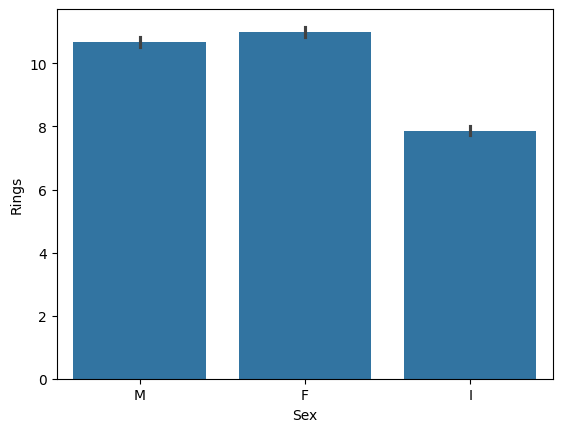

In [18]:
sns.barplot(x='Sex', y='Rings', data=df);

**Промежуточный вывод:**
- Категории в Sex почти сбалансированы.
- Средний возраст у категории Infant закономерно ниже - данные ведут себя как ожидалось.

## Многофакторный анализ

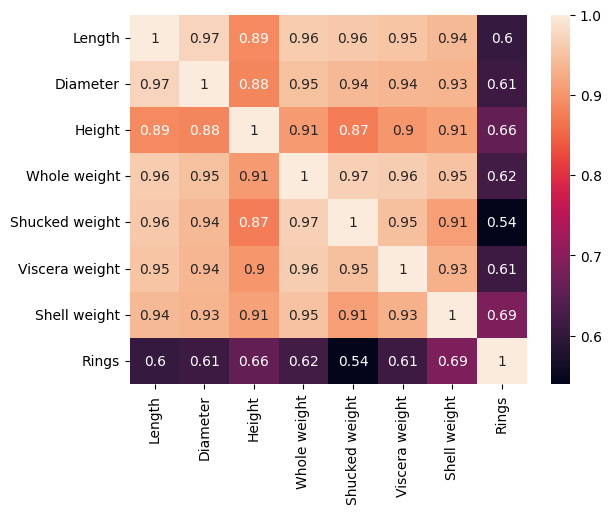

In [19]:
sns.heatmap(df.select_dtypes(include='number').corr(method='spearman'), annot=True);

**Промежуточный вывод:**
- По сравнению с корреляцией Пирсона выше, по Спирману корреляция между всеми признаками чуть выше.

In [20]:
Data = []
for c1 in df.columns:
    for c2 in df.columns:
        if df[c1].dtype == 'object' and df[c2].dtype != 'object':
            CategoryGroupLists = df.groupby(c1)[c2].apply(list)
            AnovaResults = f_oneway(*CategoryGroupLists)
            if AnovaResults[1] >= 0.05:
                Data.append({'Category' : c1, 'Numerical' : c2, 'Is correlated' : 'No'})
            else:
                Data.append({'Category' : c1, 'Numerical' : c2, 'Is correlated' : 'Yes'})
AnovaRes = pd.DataFrame.from_dict(Data)
AnovaRes

,Category,Numerical,Is correlated
0,Sex,Length,Yes
1,Sex,Diameter,Yes
2,Sex,Height,Yes
3,Sex,Whole weight,Yes
4,Sex,Shucked weight,Yes
5,Sex,Viscera weight,Yes
6,Sex,Shell weight,Yes
7,Sex,Rings,Yes


**Промежуточный вывод:**
- Между единственным категориальным признаком Sex и всеми числовыми признаками есть связь по ANOVA.

## Pandas vs Polars

In [21]:
!pip install polars

import polars as pl

print(pl.__version__)

1.35.2


In [22]:
df_big = df.copy()

for i in range(200):
  df_big = pd.concat([df_big, df])

df_big.to_csv("abalone_big.csv", index=False)

In [23]:
df_big.shape

(839577, 9)

### Загрузка данных

In [30]:
%%time

df_pl = pl.read_csv("abalone_big.csv")

CPU times: user 615 ms, sys: 3.34 ms, total: 618 ms
Wall time: 318 ms


In [31]:
%%time

df = pd.read_csv("abalone_big.csv")

CPU times: user 590 ms, sys: 98 ms, total: 688 ms
Wall time: 690 ms


### Выбор и фильтрация данных

In [32]:
%%timeit

df[['Sex', 'Rings']]

14.1 ms ± 5.23 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [33]:
%%timeit

df_pl[['Sex', 'Rings']]

15.8 µs ± 3.02 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [34]:
%%timeit

df.query('Rings > 10')

21.5 ms ± 397 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [35]:
%%timeit

df_pl.filter(pl.col('Rings') > 10)

11.7 ms ± 2.32 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


### Агрегация данных

In [36]:
%%timeit

df.groupby('Sex').agg({'Length' : 'mean', 'Rings' : 'median'})

73.4 ms ± 886 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [37]:
%%timeit

df_pl.group_by('Sex').agg([pl.mean('Length'), pl.median('Rings')])

57.7 ms ± 11.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


**Промежуточный вывод:**
- Polars оказался быстрее во всём.